# Determine sex and clean up combined adata object

Run in terminal

In [1]:
# eval "$(conda shell.bash hook)"
# conda init
# conda activate /work/islet_cartography_scrna/scrna_cartography_py_analysis
# python -m ipykernel install --user --name scrna_cartography_py_analysis --display-name "py_analysis"

Load Packages

In [2]:
# https://docs.scvi-tools.org/en/stable/tutorials/notebooks/scrna/tabula_muris.html
import os
import sys
import glob
from pyhere import here

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path
from scipy import sparse
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# colors
import tol_colors as tc

# My modules / functions
sys.path.append(str(here('scripts/misc')))  
import my_anndata as ma

## Setup Parameters

In [3]:
ma.create_directories(dir_path = str(here('data/misc_plots')))

# Plot dir
plot_dir = str(here('data/misc_plots'))
save_dir = str(here('data/anndata/'))

/work/islet_cartography_scrna/data/misc_plots Directory already exists!


In [4]:
# Plotting
sc.set_figure_params(figsize=(5, 5), frameon=False)
sns.set_theme(style="white", palette=None)
torch.set_float32_matmul_precision("high")

sc.settings.figdir = plot_dir

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

## Load data

In [5]:
# Gene id to gene name map
genes =pd.read_csv(here('genome_files/gene_id_map.csv'), index_col = 0)
# Create dictionary
gene_map = genes['gene_name_unique'].to_dict()

In [6]:
# Meta data
metadata = pd.read_csv(here('data/metadata_harmonized/metadata_combined_harmonized.csv'), index_col= 0, low_memory=False)

In [7]:
# Sex specific genes from https://pubmed.ncbi.nlm.nih.gov/23829492/
male=['RPS4Y1', 'EIF1AY', 'DDX3Y', 'KDM5D']
female=['XIST']

In [8]:
adata=sc.read_h5ad(str(here("data/anndata/A_combined.h5ad")))

# Add information to anndata object

## Add meta data

In [9]:
# Find common barcodes
common_barcodes = adata.obs.index.intersection(metadata.index)
print(f"Number of matching barcodes: {len(common_barcodes)}")

# Subset metadata to matching barcodes and reorder
meta_sub = metadata.loc[common_barcodes].reindex(adata.obs.index)

# Assert equal indices (strict check: same order and labels)
pd.testing.assert_index_equal(meta_sub.index, adata.obs.index)

# Identify only the new columns
new_cols = [col for col in meta_sub.columns if col not in adata.obs.columns]
if not new_cols:
    raise ValueError("No new columns found in metadata to add.")

# Add new metadata columns to adata.obs
adata.obs = pd.concat([adata.obs, meta_sub[new_cols]], axis=1)

# Check for duplicate columns
dupes = adata.obs.columns[adata.obs.columns.duplicated()]
if len(dupes) > 0:
    print("Warning: duplicated columns found:", dupes.tolist())

Number of matching barcodes: 589202


## Add gene symbol annotation to anndata object

In [10]:
# add gene symbol to adata
adata.var["gene_symbol"] = adata.var_names.map(gene_map)

In [11]:
# Sanify check that ensembl ids and gen enames are the correct order
print('Head of gene symbols')
print(adata.var[["gene_symbol"]].head())

print('')
print('Are the ensembl ids and gene names matched correctly:')

for ensembl_id in ['ENSG00000229807.12', 'ENSG00000114374.13', 'ENSG00000183878.15']:
    print(ensembl_id, adata.var.loc[ensembl_id, "gene_symbol"])

Head of gene symbols
                   gene_symbol
ENSG00000223972.5      DDX11L1
ENSG00000227232.5       WASH7P
ENSG00000278267.1    MIR6859-1
ENSG00000243485.5  MIR1302-2HG
ENSG00000284332.1    MIR1302-2

Are the ensembl ids and gene names matched correctly:
ENSG00000229807.12 XIST
ENSG00000114374.13 USP9Y
ENSG00000183878.15 UTY


## Change ensembl gene names to gene symbols

In [12]:
# save ensembl ids
adata.var["ensembl_id"] = adata.var_names
  
# Add var names 
adata.var_names = adata.var["gene_symbol"]

## Determine and add sex of donors

Determine sex of donors

*Some studies only have "gender" stated in the metadata. Gender is propaply self-reported, and is not always the same as biological "sex", which is determined by the presence of XY or XX chromosomes.*

In [13]:
# Normalize gene expression
# Move count data to 'counts' slot - so counts are not normalized, only by gene length are in counts. so remember to use that for the model
adata.layers["counts"] = adata.X.copy() 

# Normalize 
sc.pp.normalize_total(adata, target_sum=1e4) # Normalize so that all cells has the same total count

# log transform
sc.pp.log1p(adata)

In [14]:
# Get pseudobulk counts (sum)
counts=sc.get.aggregate(adata=adata, by='ic_id_donor_integrate', func='sum', layer='counts')

In [15]:
# Add sex and gender to new pseudo adata object
counts.obs=pd.concat([counts.obs, adata.obs[['ic_id_donor_integrate', 'sex', 'gender']].reset_index(drop=True).drop_duplicates().set_index('ic_id_donor_integrate')], axis=1)

In [16]:
# Get sum of male and female gene counts, normalized to the same library size
counts_df=pd.DataFrame(counts.layers['sum'].T, index=counts.var_names, columns=counts.obs_names)
col_sums = counts_df.sum(axis=0)
male_counts=counts_df.loc[male].sum(axis=0) / col_sums * 1e4
female_counts=counts_df.loc[female].sum(axis=0) / col_sums * 1e4

In [17]:
# Generate dataframe for plotting
plot_df = pd.DataFrame({
    "m": male_counts,
    "f": female_counts,
    "sex": counts.obs['sex'].fillna('Missing'),
    "gender": counts.obs['gender'].fillna('Missing'),
    "ic_id_donor_integrate": counts.obs['ic_id_donor_integrate']
})

plot_df.shape

(270, 5)

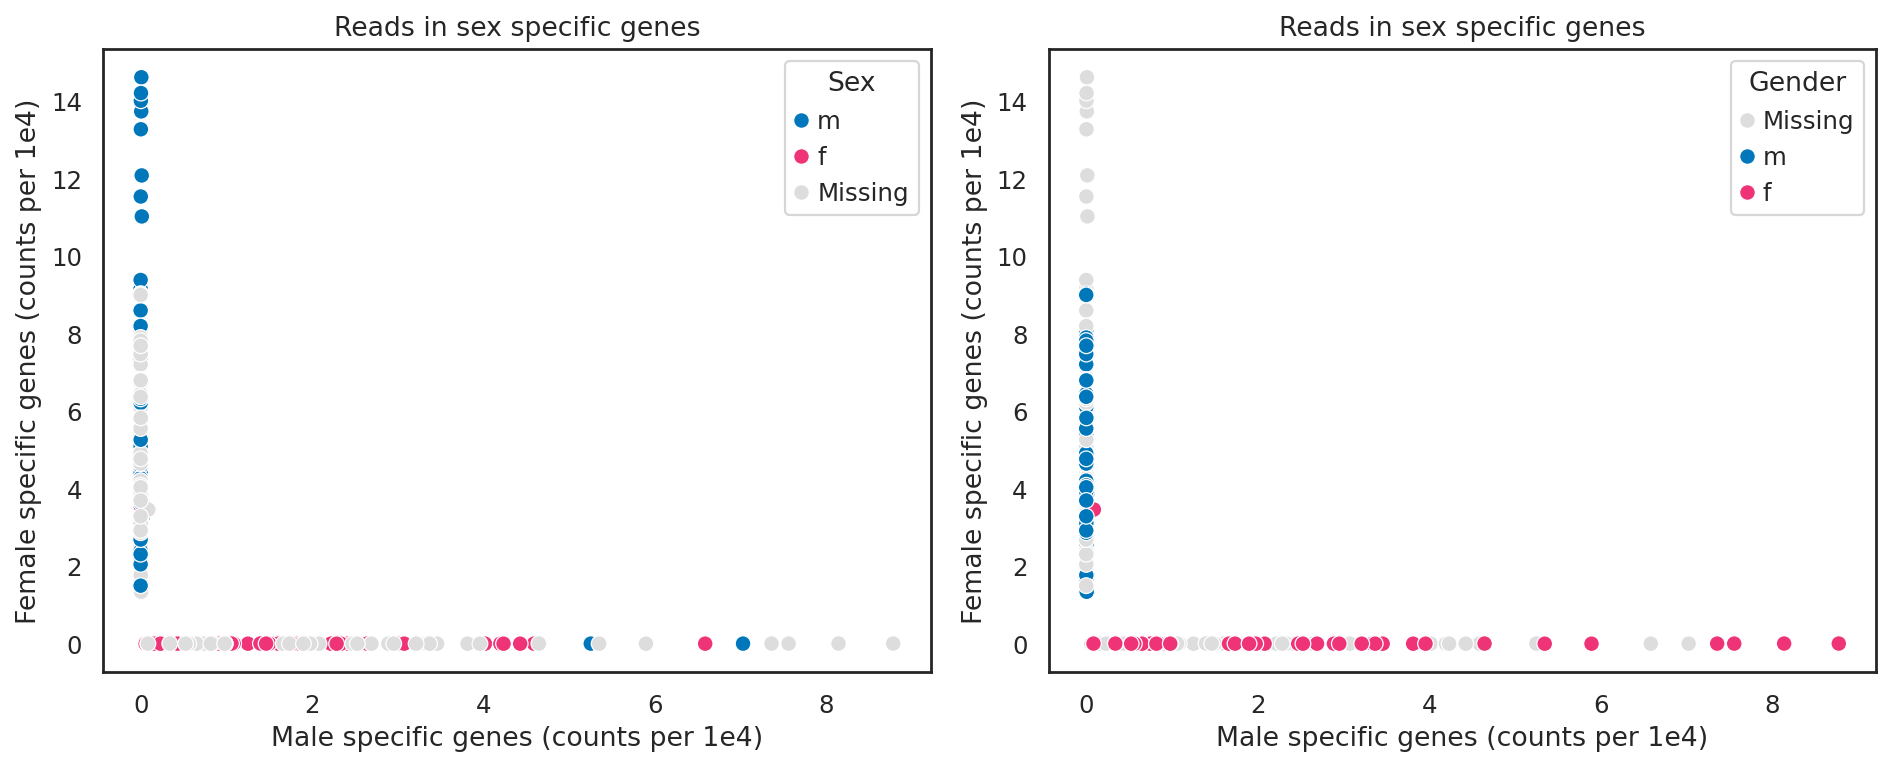

In [18]:
# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

# First plot
plot=sns.scatterplot(data=plot_df, x="f", y="m", hue='sex', s = 50, palette={'Missing':'#DDDDDD', 'f':'#EE3377', 'm':'#0077BB'}, ax=axes[0]) 
axes[0].set_title("Reads in sex specific genes")
axes[0].set_xlabel("Male specific genes (counts per 1e4)")
axes[0].set_ylabel("Female specific genes (counts per 1e4)")
axes[0].legend(title="Sex")

# Second plot (example, you can change variables)
plot=sns.scatterplot(data=plot_df, x="f", y="m", hue='gender', s = 50, palette={'Missing':'#DDDDDD', 'f':'#EE3377', 'm':'#0077BB'}, ax=axes[1]) 
axes[1].set_title("Reads in sex specific genes")
axes[1].set_xlabel("Male specific genes (counts per 1e4)")
axes[1].set_ylabel("Female specific genes (counts per 1e4)")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()

In [19]:
# Extract donors that might have the wrong annotation
# Those that may truely be men, but are noted as female in gender or sex
# or
# Those that may truely be female, but are noted as male in gender or sex
discreptency=plot_df[
    ((plot_df["m"] > plot_df["f"]) & ((plot_df["sex"] == "f") | (plot_df["gender"] == "f")))
    |
    ((plot_df["m"] < plot_df["f"]) & ((plot_df["sex"] == "m") | (plot_df["gender"] == "m")))
]
discreptency

,m,f,sex,gender,ic_id_donor_integrate
ic_12_1,0.001967,5.251235,m,Missing,ic_12_1
ic_14_1,0.000000,3.369769,m,Missing,ic_14_1
ic_16_3,0.001654,7.027697,m,Missing,ic_16_3
ic_19_6,0.001532,1.710607,m,Missing,ic_19_6
ic_3_23,3.556268,0.000000,f,Missing,ic_3_23
ic_891011_26,3.462934,0.089382,Missing,f,ic_891011_26


In [20]:
meta_filt=metadata[metadata['ic_id_donor_integrate'].isin(discreptency.index)] 
meta_filt[['ic_id_donor_integrate', 'name', 'donor', 'gender', 'sex']].reset_index(drop=True).drop_duplicates()

,ic_id_donor_integrate,name,donor,gender,sex
0,ic_3_23,Camunas,R260,NaN,f
78,ic_891011_26,HPAP_10x,HPAP-090,f,NaN
9783,ic_891011_26,HPAP_patch_23,HPAP-090,f,NaN
9853,ic_12_1,Kang_cell,HP20240,NaN,m
17648,ic_12_1,Kang_nuclei,HP20240,NaN,m
23669,ic_14_1,Mauvais_Jarvis,Islet_r1,NaN,m
28673,ic_16_3,Muraro,Donor_D30,NaN,m
29441,ic_19_6,Son,T2D2,NaN,m


In [21]:
df=plot_df
df["sex_predicted"] = np.where(df['m'] > df['f'], 'm', np.where(df['f'] > df['m'], 'f', 'Tie'))

## Add predicted sex to adata object

In [22]:
# Combine df with our adata obs, and remeber to reset index
new_adata=pd.merge(adata.obs.reset_index(), df[['ic_id_donor_integrate', 'sex_predicted']], on='ic_id_donor_integrate', how="left").set_index('index').rename_axis(index=None)

In [23]:
# Check index equality before adding new_adata to the adata object
try:
    pd.testing.assert_index_equal(adata.obs.index, new_adata.index)

    # Find the extra column(s) in new_adata
    extra_cols = new_adata.columns.difference(adata.obs.columns)

    if len(extra_cols) == 0:
        raise ValueError("No new columns found in new_adata.")
        
    # Add just the new column(s) to adata.obs
    for col in extra_cols:
        adata.obs[col] = new_adata[col]
    
except AssertionError:
    raise ValueError("Indices of adata.obs and new_adata do not match.")

## Save adata object

In [24]:
adata.write(os.path.join(save_dir, 'AB_combined.h5ad')) 